# 03 · H1: Do oil price increases worsen India's terms of trade? (ARDL bounds test)

**Model.** ARDL / error-correction model (Pesaran, Shin & Smith 2001), estimated on annual data FY1970-71 to FY2024-25:

Δln ToT_t = c + α·ln ToT_{t−1} + β₁·ln P_oil,t−1 + β₂·ln P_nonoil,t−1 + Σ γ_j·Δln P_oil,t−j + Σ δ_j·Δln P_nonoil,t−j + ε_t

- **Short-run effect:** γ₀ (same-year impact of an oil price change).
- **Long-run elasticity:** −β₁/α.
- **Speed of adjustment:** α (must be negative and significant).
- **Bounds test:** F-test that α = β₁ = β₂ = 0, compared with I(0) and I(1) critical bounds (finite-sample values, Kripfganz & Schneider 2020).

**Why ARDL?** It is valid whether the regressors are I(0) or I(1) (the unit-root tests below are borderline) and works in small samples. It also separates the short run from the long run, which mirrors L13's time horizons (Cairnes–Haberler short run vs HOS long run).

**Variables:**
- ToT = national-accounts terms of trade (goods & services).
- P_oil = real crude price (oil / MUV).
- P_nonoil = real World Bank non-energy commodity index. This is a control, so the oil coefficient is not picking up a general commodity boom.

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

## 1. Unit-root tests (ADF, Phillips–Perron, KPSS, Zivot–Andrews with one structural break)

In [2]:
d = np.log(a.loc[1970:2024, ["tot_gs_na", "real_oil_avg", "real_nonenergy", "real_gold"]])
d["ntt_merch"] = np.log(a.loc[1970:2024, "ntt_rbi_chained"])
names = {"tot_gs_na": "ln ToT goods & services", "ntt_merch": "ln ToT merchandise (FY1994-)",
         "real_oil_avg": "ln real oil price", "real_nonenergy": "ln real non-energy prices", "real_gold": "ln real gold price"}
ur = pd.DataFrame({names[k]: econ.unit_root_row(d[k]) for k in names}).T
ur["ZA break year"] = ur["ZA break year"].astype("Int64")
save_table(ur, "t02_unit_roots")
ur

,ADF level p,ADF diff p,PP level p,PP diff p,KPSS level p,KPSS diff p,ZA level p,ZA break year
ln ToT goods & services,0.057,0.000,0.050,0.000,0.100,0.100,0.391,1985
ln ToT merchandise (FY1994-),0.271,0.001,0.392,0.000,0.010,0.100,0.062,2011
ln real oil price,0.053,0.000,0.050,0.000,0.013,0.100,0.533,1999
ln real non-energy prices,0.355,0.000,0.395,0.000,0.100,0.100,0.911,2005
ln real gold price,0.945,0.000,0.582,0.000,0.010,0.100,0.942,2006


**Reading.**
- ADF/PP null = unit root; KPSS null = stationary.
- All series are clearly stationary in **first differences** (diff p ≈ 0), so **none is I(2)**, which is the condition ARDL needs.
- In levels the evidence is mixed (borderline I(0)/I(1)). That is exactly the case the ARDL bounds test was designed for.

## 2. Main ARDL / error-correction estimates

In [3]:
dd = d[["tot_gs_na", "real_oil_avg", "real_nonenergy"]].dropna().copy()
dd.columns = ["lntot", "lnoil", "lnnonoil"]
yrs = dd.index; dd.index = pd.RangeIndex(len(dd))
main = econ.ardl_uecm(dd["lntot"], dd[["lnoil", "lnnonoil"]], maxlag=2)
u = main["fit"]
print("Sample FY", yrs[0], "to FY", yrs[-1], "| N =", int(u.nobs), "| ARDL order (AIC):", main["order"])
print(u.summary().tables[1])

Sample FY 1970 to FY 2024 | N = 54 | ARDL order (AIC): (1, {'lnoil': 1, 'lnnonoil': 1})
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.8692      0.522      3.579      0.001       0.819       2.919
lntot.L1         -0.3079      0.086     -3.599      0.001      -0.480      -0.136
lnoil.L1         -0.0283      0.018     -1.553      0.127      -0.065       0.008
lnnonoil.L1      -0.0766      0.056     -1.367      0.178      -0.189       0.036
D.lnoil.L0       -0.2411      0.049     -4.931      0.000      -0.339      -0.143
D.lnnonoil.L0     0.2708      0.116      2.331      0.024       0.037       0.504


In [4]:
crit = main["crit"]
rows = {
    "Short-run oil elasticity (Δln P_oil, same year)": (u.params["D.lnoil.L0"], u.bse["D.lnoil.L0"], u.pvalues["D.lnoil.L0"]),
    "Long-run oil elasticity  (−β₁/α)": (*main["lr"]["lnoil"], np.nan),
    "Long-run non-oil commodity elasticity": (*main["lr"]["lnnonoil"], np.nan),
    "Error-correction speed α": (main["alpha"], u.bse["lntot.L1"], u.pvalues["lntot.L1"]),
}
res = pd.DataFrame(rows, index=["estimate", "std. error", "p-value"]).T
res.loc["Long-run oil elasticity  (−β₁/α)", "p-value"] = 2 * (1 - __import__("scipy").stats.norm.cdf(abs(main["lr"]["lnoil"][0] / main["lr"]["lnoil"][1])))
res.loc["Long-run non-oil commodity elasticity", "p-value"] = 2 * (1 - __import__("scipy").stats.norm.cdf(abs(main["lr"]["lnnonoil"][0] / main["lr"]["lnnonoil"][1])))
save_table(res, "t03_ardl_main")
print(f"Bounds F = {main['F']:.2f};  finite-sample p-value vs I(0) bound = {main['p_I0']:.3f}, vs I(1) bound = {main['p_I1']:.3f}")
print("Critical values (rows = significance, cols = lower/upper):"); print(crit)
res

Bounds F = 4.74;  finite-sample p-value vs I(0) bound = 0.025, vs I(1) bound = 0.070
Critical values (rows = significance, cols = lower/upper):
            lower  upper
percentile              
90.000      3.316  4.316
95.000      4.023  5.134
99.000      5.694  7.030
99.900      8.168  9.908


,estimate,std. error,p-value
"Short-run oil elasticity (Δln P_oil, same year)",-0.241,0.049,0.000
Long-run oil elasticity (−β₁/α),-0.092,0.059,0.119
Long-run non-oil commodity elasticity,-0.249,0.177,0.159
Error-correction speed α,-0.308,0.086,0.001


**Interpretation.**
- **Short run:** a 10% rise in the real oil price lowers India's goods-and-services ToT by roughly 2.4% in the same fiscal year, with high significance.
- **Speed of adjustment:** about 30% of any gap from the long-run relationship closes each year. The error-correction term is negative and significant.
- **Long run:** the elasticity is small (about −0.09) and not significant. Oil shocks move India's ToT strongly but *temporarily*; over time export prices and the trade basket adjust (refining exports, L08/L16).
- **Bounds test:** the F-statistic rejects "no level relationship" against the lower I(0) bound at 5% and against the upper I(1) bound at about 7%. That is evidence for a long-run relationship at the 10% level.

## 3. Diagnostics

In [5]:
diag = pd.Series(econ.diagnostics(u, lags=2), name="p-value").to_frame()
diag["Null hypothesis"] = ["no serial correlation (2 lags)", "homoskedastic errors", "normal errors", "correct functional form"]
save_table(diag, "t05_diagnostics")
diag

,p-value,Null hypothesis
Breusch-Godfrey LM (serial corr.) p,0.901,no serial correlation (2 lags)
Breusch-Pagan (heterosked.) p,0.019,homoskedastic errors
Jarque-Bera (normality) p,0.255,normal errors
Ramsey RESET p,0.843,correct functional form


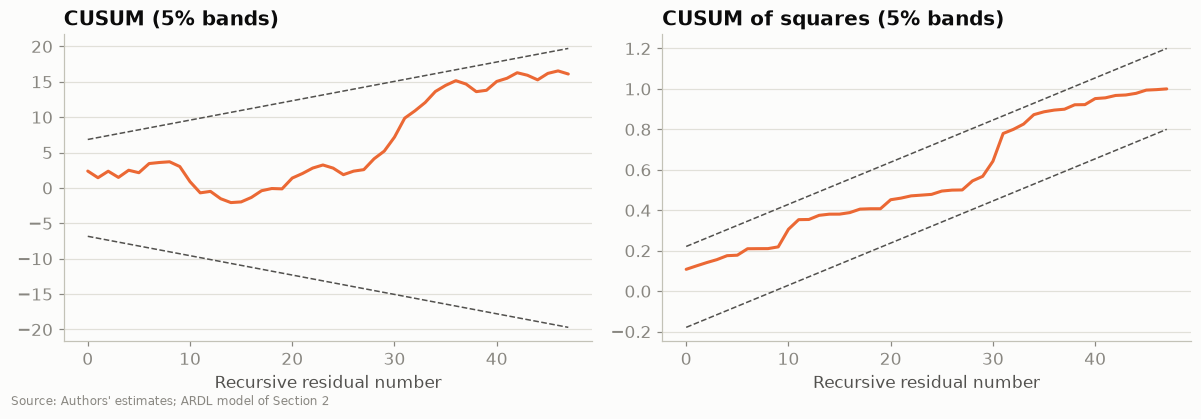

CUSUM inside bands: True | CUSUMSQ inside bands: True


In [6]:
cs = econ.cusum(u)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(cs))
ax1.plot(x, cs.cusum, color=ORANGE); ax1.plot(x, cs.band, color=INK2, lw=1, ls="--"); ax1.plot(x, -cs.band, color=INK2, lw=1, ls="--")
ax1.set_title("CUSUM (5% bands)")
ax2.plot(x, cs.cusumsq, color=ORANGE); ax2.plot(x, cs.sq_hi, color=INK2, lw=1, ls="--"); ax2.plot(x, cs.sq_lo, color=INK2, lw=1, ls="--")
ax2.set_title("CUSUM of squares (5% bands)")
for ax in (ax1, ax2): ax.set_xlabel("Recursive residual number")
fig.tight_layout()
save(fig, "fig08_cusum_stability", "Authors' estimates; ARDL model of Section 2")
plt.show()
print("CUSUM inside bands:", bool((cs.cusum.abs() <= cs.band).all()),
      "| CUSUMSQ inside bands:", bool(((cs.cusumsq <= cs.sq_hi) & (cs.cusumsq >= cs.sq_lo)).all()))

In [7]:
rob_fit = econ.as_ols(u).get_robustcov_results(cov_type="HC1")
names_ = list(u.params.index)
hc = pd.DataFrame({"coef": rob_fit.params, "HC1 s.e.": rob_fit.bse, "HC1 p-value": rob_fit.pvalues}, index=names_)
save_table(hc, "t03b_ardl_main_robust_se")
hc

,coef,HC1 s.e.,HC1 p-value
const,1.869,0.538,0.001
lntot.L1,-0.308,0.090,0.001
lnoil.L1,-0.028,0.023,0.222
lnnonoil.L1,-0.077,0.067,0.261
D.lnoil.L0,-0.241,0.040,0.000
D.lnnonoil.L0,0.271,0.095,0.006


**Reading.**
- No serial correlation, normal errors, and correct functional form (RESET) are all fine.
- The Breusch–Pagan test **does detect heteroskedasticity** (p < 0.05). The coefficients are still unbiased, but the usual standard errors are unreliable. We therefore also report **heteroskedasticity-robust (HC1) standard errors**. The short-run oil effect and the error-correction term stay clearly significant with them.
- CUSUM and CUSUMSQ stay inside the 5% bands, so the coefficients are stable over 1970–2024 (no structural break in the relationship).

## 4. Robustness: other specifications and the merchandise ToT

In [8]:
specs = [("Baseline: oil + non-oil (G&S ToT)", "tot_gs_na", ["real_oil_avg", "real_nonenergy"], 1970, 2024, 2),
         ("Oil only", "tot_gs_na", ["real_oil_avg"], 1970, 2024, 2),
         ("Oil + non-oil + gold", "tot_gs_na", ["real_oil_avg", "real_nonenergy", "real_gold"], 1970, 2024, 2),
         ("Brent instead of average crude", "tot_gs_na", ["real_brent", "real_nonenergy"], 1970, 2024, 2),
         ("Post-1980 sample", "tot_gs_na", ["real_oil_avg", "real_nonenergy"], 1980, 2024, 2),
         ("Merchandise ToT, FY1994-2024", "ntt_rbi_chained", ["real_oil_avg", "real_nonenergy"], 1994, 2024, 1)]
out = []
for name, y, xs, s, e, L in specs:
    z = np.log(a.loc[s:e, [y] + xs]).dropna(); z.index = pd.RangeIndex(len(z))
    z.columns = ["y"] + [f"x{i}" for i in range(len(xs))]
    r = econ.ardl_uecm(z["y"], z[[f"x{i}" for i in range(len(xs))]], maxlag=L, fixed=None if L > 1 else (1, {f"x{i}": 1 for i in range(len(xs))}))
    f = r["fit"]
    out.append({"Specification": name, "N": int(f.nobs), "SR oil": f.params["D.x0.L0"], "SR t": f.tvalues["D.x0.L0"],
                "LR oil": r["lr"]["x0"][0], "LR s.e.": r["lr"]["x0"][1], "ECT α": r["alpha"], "ECT t": r["alpha_t"],
                "Bounds F": r["F"], "p (I1 bound)": r["p_I1"]})
rob = pd.DataFrame(out).set_index("Specification")
save_table(rob, "t04_ardl_robustness")
rob

,N,SR oil,SR t,LR oil,LR s.e.,ECT α,ECT t,Bounds F,p (I1 bound)
Specification,,,,,,,,,
Baseline: oil + non-oil (G&S ToT),54,-0.241,-4.931,-0.092,0.059,-0.308,-3.599,4.743,0.070
Oil only,54,-0.195,-4.577,-0.084,0.075,-0.241,-2.848,4.064,0.173
Oil + non-oil + gold,54,-0.217,-4.738,-0.061,0.097,-0.310,-3.475,3.538,0.149
Brent instead of average crude,54,-0.236,-4.972,-0.089,0.058,-0.307,-3.593,4.709,0.072
Post-1980 sample,44,-0.211,-4.965,-0.192,0.108,-0.355,-3.244,3.651,0.172
"Merchandise ToT, FY1994-2024",30,-0.277,-3.457,-0.146,0.171,-0.368,-2.210,2.084,0.506


**Reading.**
- The **short-run** oil elasticity is negative and highly significant in every specification: about −0.2 to −0.3, and the strongest for merchandise trade.
- The long-run effect is small, and its significance depends on the specification.
- **Conclusion for H1:** supported. Oil price increases worsen India's ToT, mainly in the short run.